# House Price Prediction

The objective of this project is to build a machine learning model that predicts house prices using the Ames Housing dataset.

The project includes exploratory data analysis, feature engineering, regression model comparison, hyperparameter optimization, and Kaggle submission.

## 1. Exploratory Data Analysis

Train and test datasets are loaded and combined to apply the same preprocessing and feature engineering steps consistently.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=ConvergenceWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

## 1. Exploratory Data Analysis

The train and test datasets are loaded and combined to ensure consistent preprocessing and feature engineering.

In [4]:
# Load train and test datasets
train = pd.read_csv(
    "Week8/house-prices-advanced-regression-techniques/train.csv"
)

test = pd.read_csv(
    "Week8/house-prices-advanced-regression-techniques/test.csv"
)

# Check dataset dimensions
print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

Train Shape: (1460, 81)
Test Shape : (1459, 80)


In [5]:
# Combine train and test datasets
df = pd.concat(
    [train, test],
    axis=0,
    ignore_index=True
)

print("Combined Shape:", df.shape)

Combined Shape: (2919, 81)


In [6]:
# Check SalePrice values after combining datasets
print("Train SalePrice missing values:",
      train["SalePrice"].isnull().sum())

print("Combined SalePrice missing values:",
      df["SalePrice"].isnull().sum())

Train SalePrice missing values: 0
Combined SalePrice missing values: 1459


### 1.1 General Overview

Examine the general structure of the dataset, including its dimensions, data types, missing values, descriptive statistics, and unique values.

In [7]:
def check_df(dataframe, head=5):
    """
    Display general information about the dataset.
    """

    print("##################### Shape #####################")
    print(dataframe.shape)

    print("##################### Types #####################")
    print(dataframe.dtypes)

    print("##################### Head #####################")
    print(dataframe.head(head))

    print("##################### Tail #####################")
    print(dataframe.tail(head))

    print("##################### NA #####################")
    print(dataframe.isnull().sum())

    print("##################### Quantiles #####################")
    print(
        dataframe.describe(
            percentiles=[0, 0.05, 0.50, 0.95, 0.99, 1]
        ).T
    )

    print("##################### Unique Values #####################")
    print(dataframe.nunique())


check_df(df)

##################### Shape #####################
(2919, 81)
##################### Types #####################
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice        float64
Length: 81, dtype: object
##################### Head #####################
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL       65.000     8450   Pave   NaN      Reg   
1   2          20       RL       80.000     9600   Pave   NaN      Reg   
2   3          60       RL       68.000    11250   Pave   NaN      IR1   
3   4          70       RL       60.000     9550   Pave   NaN      IR1   
4   5          60       RL       84.000    14260   Pave   NaN      IR1   

  LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
0         Lvl    AllPub

### 1.2 Variable Types

Identify categorical, numerical, and cardinal categorical variables in the dataset.

In [8]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    Identify categorical, numerical and cardinal categorical variables.
    """

    # Categorical variables
    cat_cols = [
        col for col in dataframe.columns
        if str(dataframe[col].dtypes) in ["object", "category", "bool"]
    ]

    # Numerical variables with low cardinality
    num_but_cat = [
        col for col in dataframe.columns
        if dataframe[col].nunique() < cat_th
        and dataframe[col].dtypes in ["int64", "float64"]
    ]

    # Categorical variables with high cardinality
    cat_but_car = [
        col for col in dataframe.columns
        if dataframe[col].nunique() > car_th
        and str(dataframe[col].dtypes) in ["object", "category"]
    ]

    # Final categorical variables
    cat_cols = cat_cols + num_but_cat
    cat_cols = [
        col for col in cat_cols
        if col not in cat_but_car
    ]

    # Numerical variables
    num_cols = [
        col for col in dataframe.columns
        if dataframe[col].dtypes in ["int64", "float64"]
    ]

    num_cols = [
        col for col in num_cols
        if col not in cat_cols
    ]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")

    return cat_cols, num_cols, cat_but_car


cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 2919
Variables: 81
cat_cols: 52
num_cols: 28
cat_but_car: 1
num_but_cat: 10


In [9]:
len(cat_cols), len(num_cols), len(cat_but_car)

(52, 28, 1)

### 1.3 Analysis of Categorical Variables

Analyze the distribution and frequency of categorical variables in the dataset.

In [10]:
def cat_summary(dataframe, col_name, plot=False):
    """
    Display the frequency and ratio of categories
    for a categorical variable.
    """

    print(
        pd.DataFrame({
            col_name: dataframe[col_name].value_counts(),
            "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)
        })
    )

    print("##########################################")

    if plot:
        sns.countplot(
            x=dataframe[col_name],
            data=dataframe
        )
        plt.show()

In [11]:
# Analyze all categorical variables
for col in cat_cols:
    cat_summary(df, col)

          MSZoning  Ratio
MSZoning                 
RL            2265 77.595
RM             460 15.759
FV             139  4.762
RH              26  0.891
C (all)         25  0.856
##########################################
        Street  Ratio
Street               
Pave      2907 99.589
Grvl        12  0.411
##########################################
       Alley  Ratio
Alley              
Grvl     120  4.111
Pave      78  2.672
##########################################
          LotShape  Ratio
LotShape                 
Reg           1859 63.686
IR1            968 33.162
IR2             76  2.604
IR3             16  0.548
##########################################
             LandContour  Ratio
LandContour                    
Lvl                 2622 89.825
HLS                  120  4.111
Bnk                  117  4.008
Low                   60  2.055
##########################################
           Utilities  Ratio
Utilities                  
AllPub          2916 99.897
NoS

### 1.4 Analysis of Numerical Variables

Analyze the distribution and descriptive statistics of numerical variables.

In [13]:
def num_summary(dataframe, numerical_col, plot=False):
    """
    Display descriptive statistics for a numerical variable.
    """

    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40,
                 0.50, 0.60, 0.70, 0.80, 0.90,
                 0.95, 0.99]

    print(
        dataframe[numerical_col]
        .describe(quantiles)
        .T
    )

    if plot:
        dataframe[numerical_col].hist()
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)

In [14]:
# Analyze all numerical variables
for col in num_cols:
    num_summary(df, col)

count   2919.000
mean    1460.000
std      842.787
min        1.000
5%       146.900
10%      292.800
20%      584.600
30%      876.400
40%     1168.200
50%     1460.000
60%     1751.800
70%     2043.600
80%     2335.400
90%     2627.200
95%     2773.100
99%     2889.820
max     2919.000
Name: Id, dtype: float64
count   2919.000
mean      57.138
std       42.518
min       20.000
5%        20.000
10%       20.000
20%       20.000
30%       20.000
40%       30.000
50%       50.000
60%       60.000
70%       60.000
80%       80.000
90%      120.000
95%      160.000
99%      190.000
max      190.000
Name: MSSubClass, dtype: float64
count   2433.000
mean      69.306
std       23.345
min       21.000
5%        32.000
10%       43.000
20%       53.000
30%       60.000
40%       63.000
50%       68.000
60%       73.000
70%       78.000
80%       84.000
90%       95.000
95%      107.000
99%      135.680
max      313.000
Name: LotFrontage, dtype: float64
count     2919.000
mean     10168.114
std

### 1.5 Target Variable Analysis

Analyze the distribution of the target variable `SalePrice` and examine its relationship with categorical variables.

In [15]:
# Descriptive statistics of the target variable
df["SalePrice"].describe().T

count     1460.000
mean    180921.196
std      79442.503
min      34900.000
25%     129975.000
50%     163000.000
75%     214000.000
max     755000.000
Name: SalePrice, dtype: float64

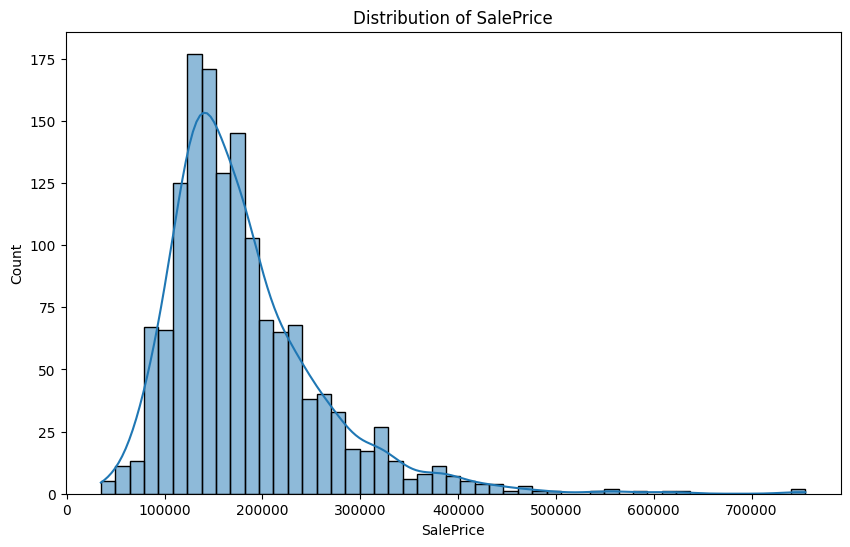

In [16]:
# Distribution of SalePrice
plt.figure(figsize=(10, 6))

sns.histplot(
    df["SalePrice"].dropna(),
    kde=True
)

plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.show()

In [17]:
def target_summary_with_cat(dataframe, target, categorical_col):
    """
    Display the mean target value for each category.
    """

    print(
        pd.DataFrame({
            "TARGET_MEAN":
                dataframe.groupby(categorical_col)[target].mean()
        }),
        end="\n\n\n"
    )

In [18]:
# Analyze target mean by categorical variables
for col in cat_cols:
    target_summary_with_cat(df, "SalePrice", col)

          TARGET_MEAN
MSZoning             
C (all)     74528.000
FV         214014.062
RH         131558.375
RL         191004.995
RM         126316.830


        TARGET_MEAN
Street             
Grvl     130190.500
Pave     181130.539


       TARGET_MEAN
Alley             
Grvl    122219.080
Pave    168000.585


          TARGET_MEAN
LotShape             
IR1        206101.665
IR2        239833.366
IR3        216036.500
Reg        164754.818


             TARGET_MEAN
LandContour             
Bnk           143104.079
HLS           231533.940
Low           203661.111
Lvl           180183.747


           TARGET_MEAN
Utilities             
AllPub      180950.957
NoSeWa      137500.000


           TARGET_MEAN
LotConfig             
Corner      181623.426
CulDSac     223854.617
FR2         177934.574
FR3         208475.000
Inside      176938.048


           TARGET_MEAN
LandSlope             
Gtl         179956.800
Mod         196734.138
Sev         204379.231


            TARGET_MEAN


### 1.6 Correlation Analysis

Examine the correlations between numerical variables and the target variable `SalePrice`.

In [20]:
# Select numerical variables together with the target
corr_cols = [
    col for col in num_cols
    if col != "SalePrice"
] + ["SalePrice"]

# Calculate correlations with SalePrice
correlations = (
    df[corr_cols]
    .corr()["SalePrice"]
    .sort_values(ascending=False)
)

correlations

SalePrice        1.000
OverallQual      0.791
GrLivArea        0.709
GarageArea       0.623
TotalBsmtSF      0.614
1stFlrSF         0.606
TotRmsAbvGrd     0.534
YearBuilt        0.523
YearRemodAdd     0.507
GarageYrBlt      0.486
MasVnrArea       0.477
BsmtFinSF1       0.386
LotFrontage      0.352
WoodDeckSF       0.324
2ndFlrSF         0.319
OpenPorchSF      0.316
LotArea          0.264
BsmtUnfSF        0.214
ScreenPorch      0.111
PoolArea         0.092
MoSold           0.046
3SsnPorch        0.045
BsmtFinSF2      -0.011
MiscVal         -0.021
Id              -0.022
LowQualFinSF    -0.026
MSSubClass      -0.084
EnclosedPorch   -0.129
Name: SalePrice, dtype: float64

### 1.7 Outlier Analysis

Detect potential outliers in numerical variables using the interquartile range (IQR) method.

In [21]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    """
    Calculate lower and upper limits for outlier detection.
    """

    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)

    interquantile_range = quartile3 - quartile1

    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range

    return low_limit, up_limit

In [22]:
def check_outlier(dataframe, col_name):
    """
    Check whether a numerical variable contains outliers.
    """

    low_limit, up_limit = outlier_thresholds(
        dataframe,
        col_name
    )

    if dataframe[
        (dataframe[col_name] > up_limit) |
        (dataframe[col_name] < low_limit)
    ].any(axis=None):
        return True
    else:
        return False

In [23]:
# Check outliers in numerical variables
for col in num_cols:
    if col != "SalePrice":
        print(col, check_outlier(df, col))

Id False
MSSubClass False
LotFrontage True
LotArea True
OverallQual False
YearBuilt False
YearRemodAdd False
MasVnrArea True
BsmtFinSF1 True
BsmtFinSF2 True
BsmtUnfSF False
TotalBsmtSF True
1stFlrSF True
2ndFlrSF False
LowQualFinSF True
GrLivArea True
TotRmsAbvGrd False
GarageYrBlt True
GarageArea False
WoodDeckSF True
OpenPorchSF True
EnclosedPorch True
3SsnPorch True
ScreenPorch True
PoolArea True
MiscVal True
MoSold False


### 1.8 Outlier Treatment

Replace extreme values with calculated lower and upper thresholds instead of removing observations.

In [24]:
def replace_with_thresholds(dataframe, variable):
    """
    Replace outliers with lower and upper threshold values.
    """

    low_limit, up_limit = outlier_thresholds(
        dataframe,
        variable
    )

    dataframe.loc[
        dataframe[variable] < low_limit,
        variable
    ] = low_limit

    dataframe.loc[
        dataframe[variable] > up_limit,
        variable
    ] = up_limit

In [25]:
# Replace outliers in numerical variables
for col in num_cols:
    if col != "SalePrice":
        replace_with_thresholds(df, col)

In [26]:
# Check outliers after treatment
for col in num_cols:
    if col != "SalePrice":
        print(col, check_outlier(df, col))

Id False
MSSubClass False
LotFrontage False
LotArea False
OverallQual False
YearBuilt False
YearRemodAdd False
MasVnrArea False
BsmtFinSF1 False
BsmtFinSF2 False
BsmtUnfSF False
TotalBsmtSF False
1stFlrSF False
2ndFlrSF False
LowQualFinSF False
GrLivArea False
TotRmsAbvGrd False
GarageYrBlt False
GarageArea False
WoodDeckSF False
OpenPorchSF False
EnclosedPorch False
3SsnPorch False
ScreenPorch False
PoolArea False
MiscVal False
MoSold False


### 1.9 Missing Value Analysis

Analyze missing values and distinguish between actual missing observations and variables where missingness represents the absence of a house feature.

In [27]:
def missing_values_table(dataframe, na_name=False):
    """
    Display columns containing missing values,
    their counts and percentages.
    """

    na_columns = [
        col for col in dataframe.columns
        if dataframe[col].isnull().sum() > 0
    ]

    n_miss = dataframe[na_columns].isnull().sum()
    ratio = (
        dataframe[na_columns].isnull().sum()
        / dataframe.shape[0] * 100
    )

    missing_df = pd.concat(
        [n_miss, np.round(ratio, 2)],
        axis=1,
        keys=["n_miss", "ratio"]
    )

    print(
        missing_df.sort_values(
            by="n_miss",
            ascending=False
        )
    )

    if na_name:
        return na_columns

In [28]:
na_cols = missing_values_table(
    df,
    na_name=True
)

              n_miss  ratio
PoolQC          2909 99.660
MiscFeature     2814 96.400
Alley           2721 93.220
Fence           2348 80.440
MasVnrType      1766 60.500
SalePrice       1459 49.980
FireplaceQu     1420 48.650
LotFrontage      486 16.650
GarageCond       159  5.450
GarageYrBlt      159  5.450
GarageFinish     159  5.450
GarageQual       159  5.450
GarageType       157  5.380
BsmtExposure      82  2.810
BsmtCond          82  2.810
BsmtQual          81  2.770
BsmtFinType2      80  2.740
BsmtFinType1      79  2.710
MasVnrArea        23  0.790
MSZoning           4  0.140
Functional         2  0.070
BsmtHalfBath       2  0.070
BsmtFullBath       2  0.070
Utilities          2  0.070
KitchenQual        1  0.030
TotalBsmtSF        1  0.030
BsmtUnfSF          1  0.030
GarageCars         1  0.030
GarageArea         1  0.030
BsmtFinSF2         1  0.030
BsmtFinSF1         1  0.030
Exterior2nd        1  0.030
Exterior1st        1  0.030
SaleType           1  0.030
Electrical         1

In [29]:
no_cols = [
    "Alley",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature"
]

In [30]:
# Fill structural missing values with "No"
for col in no_cols:
    df[col] = df[col].fillna("No")

In [31]:
missing_values_table(df)

              n_miss  ratio
MasVnrType      1766 60.500
SalePrice       1459 49.980
LotFrontage      486 16.650
GarageYrBlt      159  5.450
MasVnrArea        23  0.790
MSZoning           4  0.140
BsmtFullBath       2  0.070
BsmtHalfBath       2  0.070
Functional         2  0.070
Utilities          2  0.070
Exterior2nd        1  0.030
BsmtFinSF1         1  0.030
BsmtFinSF2         1  0.030
BsmtUnfSF          1  0.030
Exterior1st        1  0.030
Electrical         1  0.030
KitchenQual        1  0.030
GarageCars         1  0.030
GarageArea         1  0.030
SaleType           1  0.030
TotalBsmtSF        1  0.030


In [32]:
# Fill remaining categorical missing values with mode
for col in df.columns:
    if df[col].dtype == "object" and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [33]:
# Fill remaining numerical missing values with median
for col in df.columns:
    if (
        df[col].dtype != "object"
        and col != "SalePrice"
        and df[col].isnull().sum() > 0
    ):
        df[col] = df[col].fillna(df[col].median())

In [34]:
missing_values_table(df)

           n_miss  ratio
SalePrice    1459 49.980


In [35]:
df.isnull().sum()[df.isnull().sum() > 0]

SalePrice    1459
dtype: int64

## 2. Feature Engineering

Create new features from existing variables to provide additional information about the structural characteristics, size, age, and overall functionality of the houses.

In [37]:
# Interaction features between living area and floor/basement areas
df["NEW_1st*GrLiv"] = df["1stFlrSF"] * df["GrLivArea"]
df["NEW_Garage*GrLiv"] = df["GarageArea"] * df["GrLivArea"]


# Total finished floor area
df["NEW_TotalFlrSF"] = (
    df["1stFlrSF"] +
    df["2ndFlrSF"]
)


# Total finished house area including basement
df["NEW_TotalHouseArea"] = (
    df["NEW_TotalFlrSF"] +
    df["TotalBsmtSF"]
)


# Overall square footage
df["NEW_TotalSqFeet"] = (
    df["GrLivArea"] +
    df["TotalBsmtSF"]
)


# Total porch and outdoor area
df["NEW_TotalPorchArea"] = (
    df["OpenPorchSF"] +
    df["3SsnPorch"] +
    df["EnclosedPorch"] +
    df["ScreenPorch"] +
    df["WoodDeckSF"]
)


# Total number of bathrooms
# Half bathrooms are weighted as 0.5
df["NEW_TotalBathrooms"] = (
    df["FullBath"] +
    df["BsmtFullBath"] +
    0.5 * df["HalfBath"] +
    0.5 * df["BsmtHalfBath"]
)


# Overall house quality score
df["NEW_OverallGrade"] = (
    df["OverallQual"] *
    df["GrLivArea"]
)


# Garage quality-size interaction
df["NEW_GarageGrade"] = (
    df["GarageQual"].replace({
        "Ex": 5,
        "Gd": 4,
        "TA": 3,
        "Fa": 2,
        "Po": 1,
        "No": 0
    }) *
    df["GarageArea"]
)

In [38]:
# Age of the house at the time of sale
df["NEW_HouseAge"] = (
    df["YrSold"] -
    df["YearBuilt"]
)


# Years since the last remodel
df["NEW_RemodAge"] = (
    df["YrSold"] -
    df["YearRemodAdd"]
)


# Age of the garage at the time of sale
df["NEW_GarageAge"] = (
    df["YrSold"] -
    df["GarageYrBlt"]
)

In [39]:
# Indicates whether the house has been remodeled
df["NEW_IsRemodeled"] = (
    df["YearBuilt"] != df["YearRemodAdd"]
).astype(int)

In [40]:
# Indicates whether the house was sold in the same year it was built
df["NEW_IsNew"] = (
    df["YearBuilt"] == df["YrSold"]
).astype(int)

In [41]:
# Combined overall quality and condition score
df["NEW_OverallScore"] = (
    df["OverallQual"] +
    df["OverallCond"]
)

In [42]:
new_features = [
    col for col in df.columns
    if col.startswith("NEW_")
]

new_features

['NEW_1st*GrLiv',
 'NEW_Garage*GrLiv',
 'NEW_TotalFlrSF',
 'NEW_TotalHouseArea',
 'NEW_TotalSqFeet',
 'NEW_TotalPorchArea',
 'NEW_TotalBathrooms',
 'NEW_OverallGrade',
 'NEW_GarageGrade',
 'NEW_HouseAge',
 'NEW_RemodAge',
 'NEW_GarageAge',
 'NEW_IsRemodeled',
 'NEW_IsNew',
 'NEW_OverallScore']

In [43]:
df[new_features].head()

,NEW_1st*GrLiv,NEW_Garage*GrLiv,NEW_TotalFlrSF,NEW_TotalHouseArea,NEW_TotalSqFeet,NEW_TotalPorchArea,NEW_TotalBathrooms,NEW_OverallGrade,NEW_GarageGrade,NEW_HouseAge,NEW_RemodAge,NEW_GarageAge,NEW_IsRemodeled,NEW_IsNew,NEW_OverallScore
0,1463760.000,937080.000,1710.000,2566.000,2566.000,61.000,3.500,11970.000,1644.000,5,5.000,5.000,0,0,12
1,1592644.000,580520.000,1262.000,2524.000,2524.000,298.000,2.500,7572.000,1380.000,31,31.000,31.000,0,0,14
2,1643120.000,1085888.000,1786.000,2706.000,2706.000,42.000,3.500,12502.000,1824.000,7,6.000,7.000,1,0,12
3,1650037.000,1102314.000,1717.000,2473.000,2473.000,307.000,2.000,12019.000,1926.000,91,36.000,8.000,1,0,12
4,2516710.000,1837528.000,2198.000,3343.000,3343.000,276.000,3.500,17584.000,2508.000,8,8.000,8.000,0,0,13


In [44]:
print("Number of new features:", len(new_features))
print("Dataset shape:", df.shape)

Number of new features: 15
Dataset shape: (2919, 96)


In [45]:
df[
    ["NEW_HouseAge", "NEW_RemodAge", "NEW_GarageAge"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
NEW_HouseAge,2919.000,36.480,30.336,-1.000,7.000,35.000,54.500,136.000
NEW_RemodAge,2919.000,23.528,20.892,-2.000,4.000,15.000,43.000,60.000
NEW_GarageAge,2919.000,29.659,24.696,-118.500,7.000,29.000,46.000,114.000


### 2.5 Negative Age Correction

Negative age values created from inconsistent year information are corrected to ensure logically valid engineered features.

In [46]:
# Correct logically invalid negative age values
age_cols = [
    "NEW_HouseAge",
    "NEW_RemodAge",
    "NEW_GarageAge"
]

for col in age_cols:
    df.loc[df[col] < 0, col] = 0

In [47]:
df[
    ["NEW_HouseAge", "NEW_RemodAge", "NEW_GarageAge"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
NEW_HouseAge,2919.000,36.480,30.336,0.000,7.000,35.000,54.500,136.000
NEW_RemodAge,2919.000,23.530,20.890,0.000,4.000,15.000,43.000,60.000
NEW_GarageAge,2919.000,29.700,24.549,0.000,7.000,29.000,46.000,114.000


In [48]:
# Check the number of negative age values
for col in age_cols:
    print(col, (df[col] < 0).sum())

NEW_HouseAge 0
NEW_RemodAge 0
NEW_GarageAge 0


### Feature Engineering Summary

New variables were created to represent total living areas, bathroom capacity, house and garage age, remodeling status, and interactions between size and quality.

These features aim to capture relationships that may not be fully represented by the original variables individually.

### 2.6 Rare Category Analysis

Analyze categorical variables to identify categories with very low frequencies before encoding.

In [49]:
# Re-identify variable types after feature engineering
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 2919
Variables: 96
cat_cols: 58
num_cols: 37
cat_but_car: 1
num_but_cat: 16


In [50]:
def rare_analyser(dataframe, target, cat_cols):
    """
    Display category frequency, ratio and target mean
    for each categorical variable.
    """

    for col in cat_cols:
        print(col, ":", len(dataframe[col].value_counts()))

        print(
            pd.DataFrame({
                "COUNT": dataframe[col].value_counts(),
                "RATIO": dataframe[col].value_counts() / len(dataframe),
                "TARGET_MEAN": dataframe.groupby(col)[target].mean()
            }),
            end="\n\n\n"
        )

In [51]:
rare_analyser(
    df,
    "SalePrice",
    cat_cols
)

MSZoning : 5
          COUNT  RATIO  TARGET_MEAN
MSZoning                           
C (all)      25  0.009    74528.000
FV          139  0.048   214014.062
RH           26  0.009   131558.375
RL         2269  0.777   191004.995
RM          460  0.158   126316.830


Street : 2
        COUNT  RATIO  TARGET_MEAN
Street                           
Grvl       12  0.004   130190.500
Pave     2907  0.996   181130.539


Alley : 3
       COUNT  RATIO  TARGET_MEAN
Alley                           
Grvl     120  0.041   122219.080
No      2721  0.932   183452.131
Pave      78  0.027   168000.585


LotShape : 4
          COUNT  RATIO  TARGET_MEAN
LotShape                           
IR1         968  0.332   206101.665
IR2          76  0.026   239833.366
IR3          16  0.005   216036.500
Reg        1859  0.637   164754.818


LandContour : 4
             COUNT  RATIO  TARGET_MEAN
LandContour                           
Bnk            117  0.040   143104.079
HLS            120  0.041   231533.940
Low 

### 2.7 Rare Encoding

Categories representing less than 1% of the observations are grouped under the `Rare` category to reduce sparsity before one-hot encoding.

In [52]:
def rare_encoder(dataframe, rare_perc=0.01):
    """
    Replace categories with frequencies below the specified
    threshold with the label 'Rare'.
    """

    temp_df = dataframe.copy()

    # Find categorical columns containing rare categories
    rare_columns = [
        col for col in temp_df.columns
        if temp_df[col].dtype == "object"
        and (
            temp_df[col].value_counts() / len(temp_df) < rare_perc
        ).any()
    ]

    # Replace rare categories with "Rare"
    for col in rare_columns:

        rare_labels = (
            temp_df[col]
            .value_counts()
            / len(temp_df)
        )

        rare_labels = rare_labels[
            rare_labels < rare_perc
        ].index

        temp_df[col] = np.where(
            temp_df[col].isin(rare_labels),
            "Rare",
            temp_df[col]
        )

    return temp_df

In [53]:
# Apply rare encoding
df = rare_encoder(
    df,
    rare_perc=0.01
)

In [54]:
# Re-identify variable types after rare encoding
cat_cols, num_cols, cat_but_car = grab_col_names(df)

# Check categorical variables after rare encoding
rare_analyser(
    df,
    "SalePrice",
    cat_cols
)

Observations: 2919
Variables: 96
cat_cols: 58
num_cols: 37
cat_but_car: 1
num_but_cat: 16
MSZoning : 4
          COUNT  RATIO  TARGET_MEAN
MSZoning                           
FV          139  0.048   214014.062
RL         2269  0.777   191004.995
RM          460  0.158   126316.830
Rare         51  0.017   109623.615


Street : 2
        COUNT  RATIO  TARGET_MEAN
Street                           
Pave     2907  0.996   181130.539
Rare       12  0.004   130190.500


Alley : 3
       COUNT  RATIO  TARGET_MEAN
Alley                           
Grvl     120  0.041   122219.080
No      2721  0.932   183452.131
Pave      78  0.027   168000.585


LotShape : 4
          COUNT  RATIO  TARGET_MEAN
LotShape                           
IR1         968  0.332   206101.665
IR2          76  0.026   239833.366
Rare         16  0.005   216036.500
Reg        1859  0.637   164754.818


LandContour : 4
             COUNT  RATIO  TARGET_MEAN
LandContour                           
Bnk            117  0.040   

### 2.8 Encoding

Convert categorical variables into numerical representations suitable for machine learning models using Label Encoding and One-Hot Encoding.

In [55]:
# Re-identify variable types before encoding
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 2919
Variables: 96
cat_cols: 58
num_cols: 37
cat_but_car: 1
num_but_cat: 16


In [56]:
# Identify binary categorical variables
binary_cols = [
    col
    for col in df.select_dtypes(include=["object", "category"]).columns
    if df[col].nunique() == 2
]

binary_cols

['Street',
 'Utilities',
 'Condition2',
 'RoofMatl',
 'Heating',
 'CentralAir',
 'PoolQC']

In [57]:
def label_encoder(dataframe, binary_col):
    """
    Apply Label Encoding to a binary categorical variable.
    """

    labelencoder = LabelEncoder()

    dataframe[binary_col] = labelencoder.fit_transform(
        dataframe[binary_col]
    )

    return dataframe

In [58]:
# Apply Label Encoding
for col in binary_cols:
    df = label_encoder(df, col)

In [59]:
# Remove already encoded binary variables
# and the target variable from categorical columns
cat_cols = [
    col
    for col in cat_cols
    if col not in binary_cols
    and col != "SalePrice"
]

In [60]:
cat_cols

['MSZoning',
 'Alley',
 'LotShape',
 'LandContour',
 'LotConfig',
 'LandSlope',
 'Condition1',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'HeatingQC',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition',
 'OverallCond',
 'LowQualFinSF',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'Fireplaces',
 'GarageCars',
 '3SsnPorch',
 'PoolArea',
 'MiscVal',
 'YrSold',
 'NEW_IsRemodeled',
 'NEW_IsNew']

In [61]:
def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    """
    Apply One-Hot Encoding to categorical variables.
    """

    dataframe = pd.get_dummies(
        dataframe,
        columns=categorical_cols,
        drop_first=drop_first
    )

    return dataframe

In [62]:
# Apply One-Hot Encoding
df = one_hot_encoder(
    df,
    cat_cols,
    drop_first=True
)

In [63]:
print("Dataset shape after encoding:", df.shape)

df.head()

Dataset shape after encoding: (2919, 225)


,Id,MSSubClass,LotFrontage,LotArea,Street,Utilities,Neighborhood,Condition2,OverallQual,YearBuilt,YearRemodAdd,RoofMatl,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,CentralAir,1stFlrSF,2ndFlrSF,GrLivArea,TotRmsAbvGrd,GarageYrBlt,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,PoolQC,MoSold,SalePrice,NEW_1st*GrLiv,NEW_Garage*GrLiv,NEW_TotalFlrSF,NEW_TotalHouseArea,NEW_TotalSqFeet,NEW_TotalPorchArea,NEW_TotalBathrooms,NEW_OverallGrade,NEW_GarageGrade,NEW_HouseAge,NEW_RemodAge,NEW_GarageAge,NEW_OverallScore,MSZoning_RL,MSZoning_RM,MSZoning_Rare,Alley_No,Alley_Pave,LotShape_IR2,LotShape_Rare,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_Inside,LotConfig_Rare,LandSlope_Mod,LandSlope_Rare,Condition1_Feedr,Condition1_Norm,Condition1_PosN,Condition1_RRAn,Condition1_Rare,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1Story,HouseStyle_2Story,HouseStyle_Rare,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Hip,RoofStyle_Rare,Exterior1st_BrkFace,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Rare,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_BrkFace,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_MetalSd,Exterior2nd_Plywood,Exterior2nd_Rare,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_Rare,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Gd,ExterCond_Rare,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Rare,Foundation_Slab,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_No,BsmtQual_TA,BsmtCond_Gd,BsmtCond_No,BsmtCond_Rare,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_No,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_No,BsmtFinType2_Rec,BsmtFinType2_Unf,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Rare,HeatingQC_TA,Electrical_FuseF,Electrical_Rare,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Min2,Functional_Mod,Functional_Rare,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_No,FireplaceQu_Po,FireplaceQu_TA,GarageType_Basment,GarageType_BuiltIn,GarageType_Detchd,GarageType_No,GarageType_Rare,GarageFinish_No,GarageFinish_RFn,GarageFinish_Unf,GarageQual_No,GarageQual_Rare,GarageQual_TA,GarageCond_No,GarageCond_Rare,GarageCond_TA,PavedDrive_P,PavedDrive_Y,Fence_GdWo,Fence_MnPrv,Fence_No,Fence_Rare,MiscFeature_Rare,MiscFeature_Shed,SaleType_New,SaleType_Rare,SaleType_WD,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SaleCondition_Rare,OverallCond_2,OverallCond_3,OverallCond_4,OverallCond_5,OverallCond_6,OverallCond_7,OverallCond_8,OverallCond_9,BsmtFullBath_1.0,BsmtFullBath_2.0,BsmtFullBath_3.0,BsmtHalfBath_1.0,BsmtHalfBath_2.0,FullBath_1,FullBath_2,FullBath_3,FullBath_4,HalfBath_1,HalfBath_2,BedroomAbvGr_1,BedroomAbvGr_2,BedroomAbvGr_3,BedroomAbvGr_4,BedroomAbvGr_5,BedroomAbvGr_6,BedroomAbvGr_8,KitchenAbvGr_1,KitchenAbvGr_2,KitchenAbvGr_3,Fireplaces_1,Fireplaces_2,Fireplaces_3,Fireplaces_4,GarageCars_1.0,GarageCars_2.0,GarageCars_3.0,GarageCars_4.0,GarageCars_5.0,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,NEW_IsRemodeled_1,NEW_IsNew_1
0,1.000,60,65.000,8450.000,0,0,CollgCr,0,7,2003,2003.000,0,196.000,706.000,0.000,150.000,856.000,0,1,856.000,854.000,1710.000,8.000,2003.000,548.000,0,61.000,0,0.000,0,2.000,208500.000,1463760.000,937080.000,1710.000,2566.000,2566.000,61.000,3.500,11970.000,1644.000,5,5.000,5.000,12,True,False,False,True,False,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,Fals

In [64]:
# Check whether any object variables remain
df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

['Neighborhood']

In [66]:
# One-Hot Encode the remaining Neighborhood variable
df = pd.get_dummies(
    df,
    columns=["Neighborhood"],
    drop_first=True
)

In [67]:
# Check whether any categorical variables remain
df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

[]

### 2.9 Final Data Check

Perform a final check for missing values and non-numerical variables before model development.

In [65]:
# Check remaining missing values
df.isnull().sum()[
    df.isnull().sum() > 0
]

SalePrice    1459
dtype: int64

In [ ]:
# Check final dataset structure
print("Dataset Shape:", df.shape)
print(
    "Remaining Object Columns:",
    df.select_dtypes(include=["object", "category"]).shape[1]
)

## 3. Model Development

Split the combined dataset back into training and test sets, evaluate multiple regression algorithms using cross-validation, and compare their RMSE scores.

In [68]:
# Split the combined dataset back into train and test sets
train_df = df[df["SalePrice"].notnull()].copy()
test_df = df[df["SalePrice"].isnull()].copy()

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape: (1460, 245)
Test Shape : (1459, 245)


### 3.2 Feature Matrix and Target

Separate the target variable from the predictor variables before model evaluation.

In [69]:
# Target variable
y = train_df["SalePrice"]

# Predictor variables
# SalePrice is the target and Id is only an identifier
X = train_df.drop(
    ["SalePrice", "Id"],
    axis=1
)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1460, 243)
y Shape: (1460,)


In [70]:
# Final safety checks before modeling
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())
print(
    "Non-numerical columns in X:",
    X.select_dtypes(include=["object", "category"]).shape[1]
)

Missing values in X: 0
Missing values in y: 0
Non-numerical columns in X: 0


In [71]:
assert X.isnull().sum().sum() == 0, "X contains missing values."
assert y.isnull().sum() == 0, "y contains missing values."

### 3.3 Baseline Regression Models

Evaluate multiple regression algorithms using 5-fold cross-validation and compare their RMSE performance.

In [72]:
# Define regression models
models = [
    ("LR", LinearRegression()),
    ("Ridge", Ridge()),
    ("Lasso", Lasso()),
    ("ElasticNet", ElasticNet()),
    ("KNN", KNeighborsRegressor()),
    ("CART", DecisionTreeRegressor(random_state=17)),
    ("RF", RandomForestRegressor(random_state=17)),
    ("GBM", GradientBoostingRegressor(random_state=17)),
    ("XGBoost", XGBRegressor(random_state=17)),
    ("LightGBM", LGBMRegressor(random_state=17, verbose=-1)),
    ("CatBoost", CatBoostRegressor(random_state=17, verbose=False))
]

In [73]:
# Compare baseline regression models using 5-fold cross-validation
results = []

for name, model in models:

    rmse_scores = -cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "RMSE": rmse_scores.mean()
    })


# Create comparison table
model_results = pd.DataFrame(results)

model_results = model_results.sort_values(
    by="RMSE",
    ascending=True
)

model_results

,Model,RMSE
10,CatBoost,24027.543
7,GBM,25116.029
8,XGBoost,27866.774
9,LightGBM,27928.700
6,RF,29940.289
3,ElasticNet,31634.198
2,Lasso,31733.404
5,CART,36588.258
4,KNN,46951.088
1,Ridge,55990.522


### Baseline Model Evaluation

Among the baseline models, CatBoost achieved the lowest RMSE (24,027.543), followed by Gradient Boosting (25,116.029).

Tree-based ensemble models generally outperformed linear and distance-based models. Therefore, CatBoost and other boosting algorithms appear to be strong candidates for further model improvement.

### 3.5 Log Transformation of the Target Variable

Since `SalePrice` has a right-skewed distribution, a logarithmic transformation is applied to reduce the effect of extreme values and improve model performance.

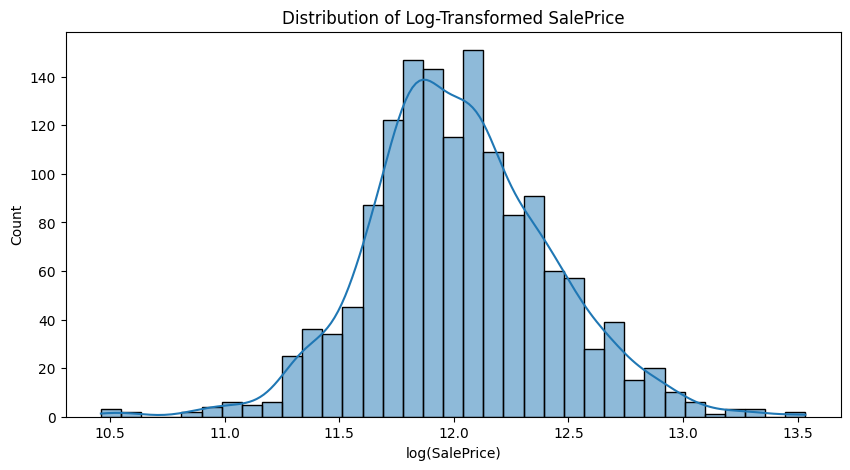

In [74]:
# Log-transform the target variable
y_log = np.log1p(y)

# Compare original and log-transformed target distributions
plt.figure(figsize=(10, 5))
sns.histplot(y_log, kde=True)
plt.title("Distribution of Log-Transformed SalePrice")
plt.xlabel("log(SalePrice)")
plt.show()

### 3.6 Baseline Models with Log-Transformed Target

Evaluate the same regression models using the log-transformed target variable and compare their cross-validation RMSE scores.

In [75]:
# Evaluate baseline models using log-transformed SalePrice
log_results = []

for name, model in models:

    rmse_scores = -cross_val_score(
        model,
        X,
        y_log,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    log_results.append({
        "Model": name,
        "Log_RMSE": rmse_scores.mean()
    })


# Create comparison table
log_model_results = pd.DataFrame(log_results)

log_model_results = log_model_results.sort_values(
    by="Log_RMSE",
    ascending=True
)

log_model_results

,Model,Log_RMSE
10,CatBoost,0.119
7,GBM,0.125
9,LightGBM,0.129
6,RF,0.136
8,XGBoost,0.141
3,ElasticNet,0.147
2,Lasso,0.155
1,Ridge,0.176
0,LR,0.188
5,CART,0.195


In [76]:
from sklearn.model_selection import cross_val_predict

# Generate cross-validated predictions using log-transformed target
log_predictions = cross_val_predict(
    CatBoostRegressor(
        random_state=17,
        verbose=False
    ),
    X,
    y_log,
    cv=5,
    n_jobs=-1
)

# Convert predictions back to original SalePrice scale
predictions_original_scale = np.expm1(log_predictions)

# Calculate RMSE on the original price scale
log_model_rmse_original_scale = np.sqrt(
    mean_squared_error(
        y,
        predictions_original_scale
    )
)

print(
    "CatBoost RMSE after Log Transformation:",
    round(log_model_rmse_original_scale, 3)
)

CatBoost RMSE after Log Transformation: 25073.612


### Log Transformation Evaluation

After converting the log-scale predictions back to the original SalePrice scale, CatBoost achieved an RMSE of 25,073.612.

The original CatBoost model achieved a lower RMSE of 24,027.543 on the original price scale. Therefore, the log transformation did not improve CatBoost's RMSE in terms of absolute house-price prediction error.

However, the log-transformed target remains relevant for the Kaggle evaluation metric, which evaluates prediction errors on a logarithmic scale.

### 3.7 Hyperparameter Optimization

Hyperparameter optimization is performed for the strongest baseline models to improve their predictive performance.

In [77]:
# CatBoost hyperparameter grid
catboost_params = {
    "iterations": [300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "depth": [4, 6, 8]
}

catboost_model = CatBoostRegressor(
    random_state=17,
    verbose=False
)

catboost_gs = GridSearchCV(
    catboost_model,
    catboost_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

catboost_gs.fit(X, y)

print("Best Parameters:")
print(catboost_gs.best_params_)

print(
    "Best RMSE:",
    round(-catboost_gs.best_score_, 3)
)

Best Parameters:
{'depth': 6, 'iterations': 500, 'learning_rate': 0.05}
Best RMSE: 24279.647


### CatBoost Hyperparameter Optimization

The best CatBoost parameters were found as `depth=6`, `iterations=500`, and `learning_rate=0.05`.

However, the tuned CatBoost model achieved an RMSE of 24,279.647, which was slightly higher than the baseline CatBoost RMSE of 24,027.543. Therefore, hyperparameter tuning did not improve the baseline CatBoost model.

### GBM and XGBoost Hyperparameter Optimization

Hyperparameter optimization is performed for GBM and XGBoost to determine whether their baseline performances can be improved.

In [78]:
# GBM hyperparameter grid
gbm_params = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [300, 500],
    "max_depth": [2, 3, 4]
}

gbm_model = GradientBoostingRegressor(
    random_state=17
)

gbm_gs = GridSearchCV(
    gbm_model,
    gbm_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

gbm_gs.fit(X, y)

print("Best GBM Parameters:")
print(gbm_gs.best_params_)

print(
    "Best GBM RMSE:",
    round(-gbm_gs.best_score_, 3)
)

Best GBM Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500}
Best GBM RMSE: 24368.177


In [79]:
# XGBoost hyperparameter grid
xgb_params = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [300, 500],
    "max_depth": [3, 5, 7]
}

xgb_model = XGBRegressor(
    random_state=17,
    objective="reg:squarederror"
)

xgb_gs = GridSearchCV(
    xgb_model,
    xgb_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

xgb_gs.fit(X, y)

print("Best XGBoost Parameters:")
print(xgb_gs.best_params_)

print(
    "Best XGBoost RMSE:",
    round(-xgb_gs.best_score_, 3)
)

Best XGBoost Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}
Best XGBoost RMSE: 25280.467


### Hyperparameter Optimization Results

Hyperparameter tuning improved the performance of GBM and XGBoost, while CatBoost did not outperform its baseline result.

The baseline CatBoost model achieved the lowest overall RMSE (24,027.543), making it the strongest model based on the original SalePrice scale.

In [80]:
# Compare baseline and tuned model performances
comparison_results = pd.DataFrame({
    "Model": [
        "CatBoost Baseline",
        "CatBoost Tuned",
        "GBM Baseline",
        "GBM Tuned",
        "XGBoost Baseline",
        "XGBoost Tuned"
    ],
    "RMSE": [
        24027.543,
        24279.647,
        25116.029,
        24368.177,
        27866.774,
        25280.467
    ]
})

comparison_results.sort_values(
    by="RMSE",
    ascending=True
)

,Model,RMSE
0,CatBoost Baseline,24027.543
1,CatBoost Tuned,24279.647
3,GBM Tuned,24368.177
2,GBM Baseline,25116.029
5,XGBoost Tuned,25280.467
4,XGBoost Baseline,27866.774


### 3.11 Final Model

Based on cross-validation results, the baseline CatBoost model achieved the lowest RMSE and was selected as the final model.

The final model is trained on the complete training dataset and used to predict SalePrice values for the Kaggle test dataset.

In [81]:
# Prepare the Kaggle test dataset
X_test = test_df.drop(
    ["SalePrice", "Id"],
    axis=1
)

print("X Train Shape:", X.shape)
print("X Test Shape :", X_test.shape)

X Train Shape: (1460, 243)
X Test Shape : (1459, 243)


In [82]:
# Check whether train and test features are identical
print(
    "Train and test columns match:",
    X.columns.equals(X_test.columns)
)

Train and test columns match: True


In [83]:
# Train the final CatBoost model
final_model = CatBoostRegressor(
    random_state=17,
    verbose=False
)

final_model.fit(X, y)

CatBoostRegressor(loss_function='RMSE', random_state=17, verbose=False)

In [84]:
# Predict SalePrice for the test dataset
test_predictions = final_model.predict(X_test)

test_predictions[:10]

array([120665.54278684, 165531.96631565, 182862.70061754, 198751.80495417,
       184789.80786059, 173166.86392937, 179534.75811827, 166155.77969666,
       186966.86482947, 120374.03378804])

In [85]:
# Create Kaggle submission file
submission = pd.DataFrame({
    "Id": test_df["Id"].astype(int),
    "SalePrice": test_predictions
})

submission.head()

,Id,SalePrice
1460,1461,120665.543
1461,1462,165531.966
1462,1463,182862.701
1463,1464,198751.805
1464,1465,184789.808


In [86]:
print("Submission Shape:", submission.shape)
print("Missing Predictions:", submission["SalePrice"].isnull().sum())

Submission Shape: (1459, 2)
Missing Predictions: 0


In [87]:
# Save submission file
submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv successfully created.")

submission.csv successfully created.


### 3.12 Feature Importance

Feature importance values of the final CatBoost model are examined to identify the variables that contribute most to house price predictions.

In [88]:
# Get feature importance values from the final model
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

# Select the 20 most important features
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

feature_importance

,Feature,Importance
36,NEW_OverallGrade,17.431
6,OverallQual,8.060
33,NEW_TotalSqFeet,7.044
32,NEW_TotalHouseArea,6.460
11,BsmtFinSF1,3.009
41,NEW_OverallScore,3.001
29,NEW_1st*GrLiv,2.801
2,LotArea,2.410
14,TotalBsmtSF,2.282
7,YearBuilt,2.176


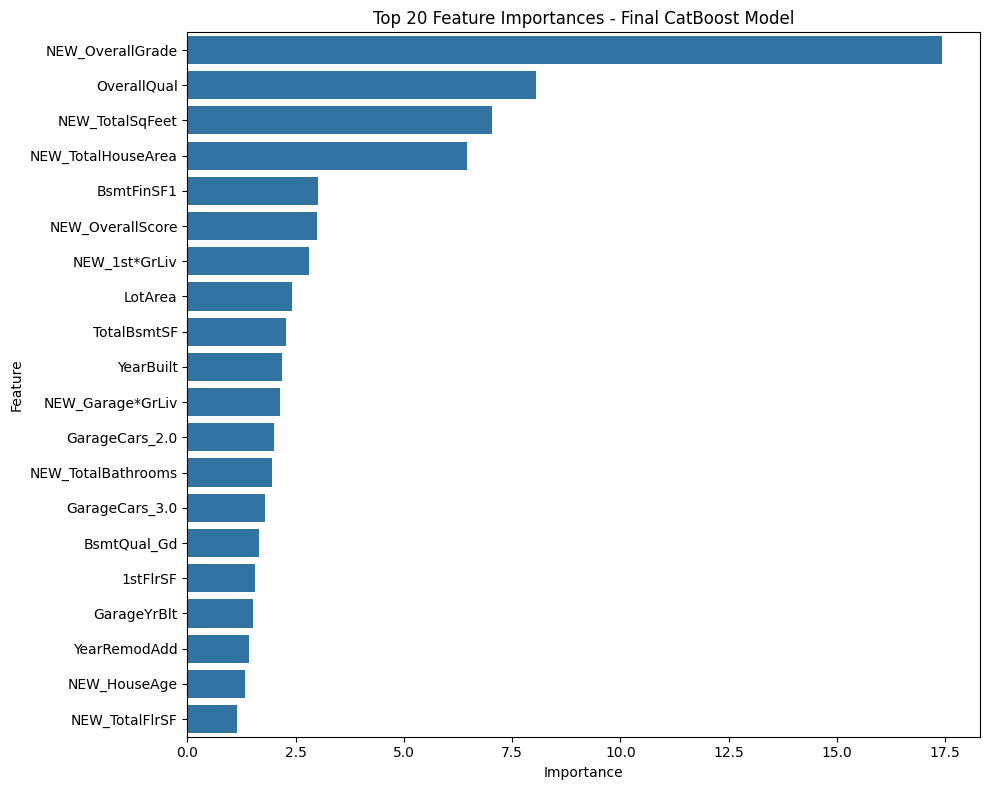

In [89]:
# Visualize the top 20 most important features
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances - Final CatBoost Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature Importance Evaluation

The feature importance analysis shows that both original and engineered variables contribute substantially to the final model.

`NEW_OverallGrade` was the most influential feature, followed by `OverallQual`, `NEW_TotalSqFeet`, and `NEW_TotalHouseArea`. Several engineered features ranked among the top predictors, indicating that the feature engineering process successfully captured additional information relevant to house price prediction.

## 4. Conclusion

In this project, exploratory data analysis, missing value treatment, outlier analysis, feature engineering, rare encoding, and categorical variable encoding were applied to the House Prices dataset.

Several regression algorithms were evaluated using 5-fold cross-validation. CatBoost achieved the best baseline performance with an RMSE of 24,027.543.

Hyperparameter optimization improved the performance of GBM and XGBoost, while the baseline CatBoost model remained the best-performing model overall.

The final CatBoost model was trained on the complete training dataset and used to generate SalePrice predictions for the Kaggle test dataset. The predictions were saved as `submission.csv`.